In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import adam_config, opes_config, data, adam_hash, hash_configs
import json

# TODO: fix so that it is easy to run either with fixed dF or updating dF. Need to increase maximum temp. Maybe increase number of shared chains for this as well.:)


In [2]:
base_dir = Path.cwd()
adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
sp = np.load(adam_dir / "adam_samples.npy")
energies = np.load(adam_dir / "adam_energies.npy")
d18o_energies = np.load(adam_dir / "adam_d18o_energies.npy")

indices = np.argsort(energies)
sp = sp[indices][:opes_config["hmcc"]["nch"]]
opes_config["hmcc"]["sp"] = np.ascontiguousarray(sp)
opes_config["ee"] = np.mean(d18o_energies)
opes_hash = hash_configs(opes_config, data)
output_dir = adam_dir / f"{opes_hash}"

hmc_config = opes_config["hmcc"]

In [3]:
colors = plt.cm.viridis(np.linspace(0, 1, hmc_config["nch"]))
temp_colors = plt.cm.viridis(np.linspace(0,1, opes_config["nt"]))

In [4]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [5]:
starting_energies = np.load(adam_dir / "adam_energies.npy")
starting_points= np.load(adam_dir / "adam_samples.npy")

idx = np.argsort(starting_energies)
starting_energies_sorted = starting_energies[idx]

sp_energies = starting_energies_sorted[:hmc_config["nch"]]
sp = starting_points[idx][:hmc_config["nch"], :]

(5, 51)


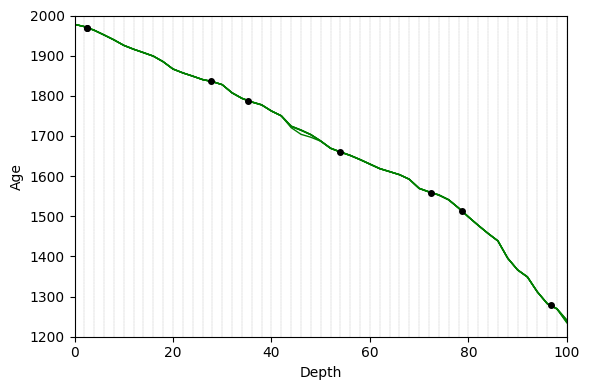

In [6]:

cumulative_sums = np.cumsum(sp, axis=1) * data["dc"]
zeros = np.zeros((*sp.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(sp)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{adam_dir}/sp_age_depth.jpg")
plt.show()

(100, 51)


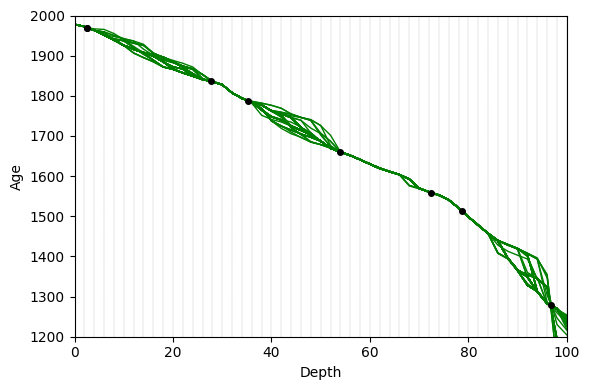

In [7]:

cumulative_sums = np.cumsum(starting_points, axis=1) * data["dc"]
zeros = np.zeros((*starting_points.shape[:1], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=1)
print(np.shape(age_offsets))

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(starting_points)
for j in range(num_samples):
    ax.plot(
        data["cs"],
        model_ages[j, :],
        color='green',
        alpha=1,
        linewidth=1,
    )
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{adam_dir}/all_sp_age_depth.jpg")
plt.show()

In [8]:
samples = np.load(f"{output_dir}/samples.npy")

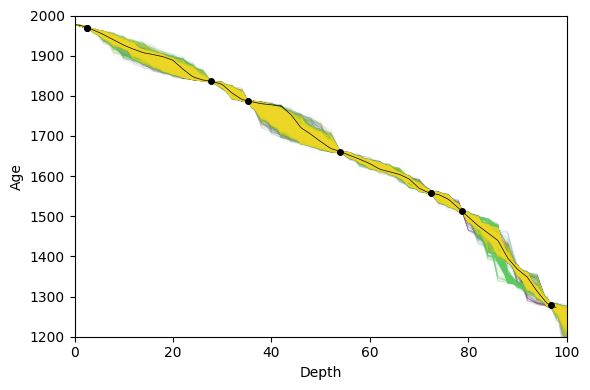

In [9]:
cumulative_sums = np.cumsum(samples, axis=2) * data["dc"]
zeros = np.zeros((*samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(samples[0,:,0])
for i in range(hmc_config["nch"]):
    for j in range(num_samples):
        ax.plot(
            data["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth_samples.jpg")
plt.show()

In [10]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(samples)
summary = az.summary(idata, round_to=2)
print(summary)

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.85   0.35    2.19     3.54       0.00     0.00  19655.93  18246.34   
x[1]    4.66   1.03    2.68     6.61       0.01     0.02  20834.02  11777.07   
x[2]    5.67   1.64    2.05     8.57       0.02     0.03   9835.77   5478.55   
x[3]    6.29   2.24    2.07    10.75       0.03     0.04   6481.57   7007.53   
x[4]    6.10   2.48    1.28    10.16       0.04     0.04   3422.26   6104.27   
x[5]    5.21   2.57    1.19     9.87       0.04     0.06   5097.41   4820.34   
x[6]    5.41   2.83    1.15    10.87       0.05     0.05   3851.20   6027.04   
x[7]    4.65   2.65    0.83     9.55       0.05     0.04   2697.53   5384.82   
x[8]    5.39   2.91    0.87    10.39       0.08     0.04   1119.18   5710.28   
x[9]    7.14   3.77    0.98    13.51       0.14     0.04    774.33   4459.40   
x[10]   5.34   2.93    0.79    10.51       0.08     0.12   1833.00   2030.00   
x[11]   5.42   3.49    0.82    12.51    

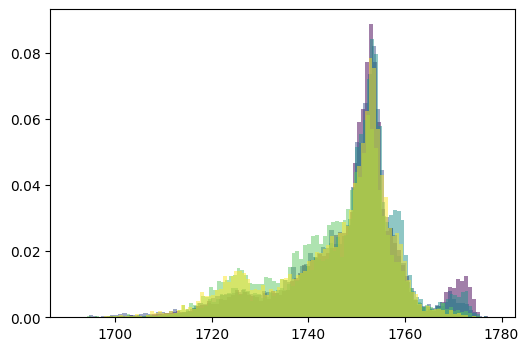

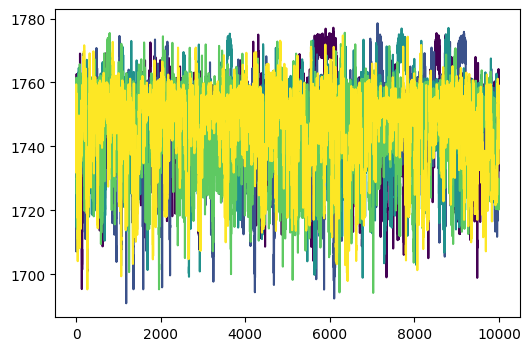

In [11]:
index = 21
interesting_depth = index * data["dc"]
CV_values = data["th"] - data["dc"] * np.sum(samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.savefig(f"{output_dir}/sampling_along_depth_evolution_{interesting_depth}.jpg")
plt.show()

In [12]:
bias_values = np.load(f"{output_dir}/bias.npy")
energy_values = np.load(f"{output_dir}/energy.npy")

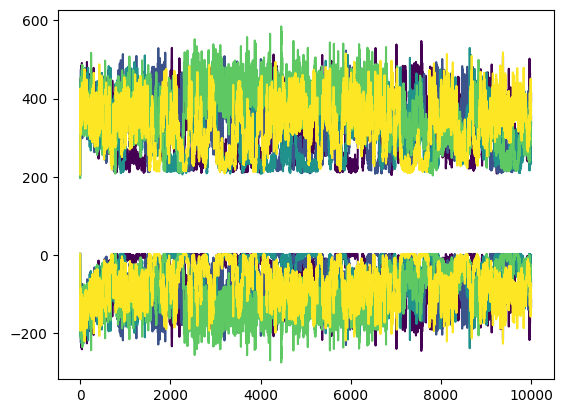

In [13]:
plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
    plt.plot(energy_values[i,:], color = colors[i])
plt.savefig(f"{output_dir}/energy_and_bias.jpg")
plt.show()

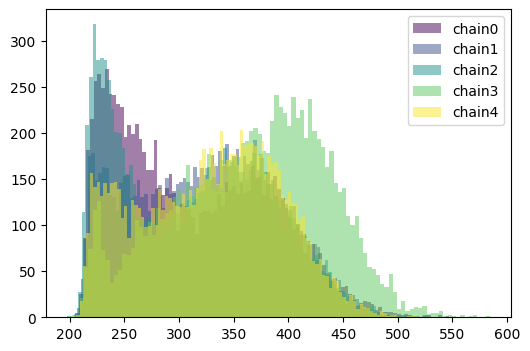

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(hmc_config["nch"]):
    ax.hist(energy_values[i, :], color = colors[i], alpha = 0.5, label = f"chain{i}", bins = 100)
plt.legend()
plt.savefig(f"{output_dir}/energy_hist.jpg")
plt.show()   

In [15]:
resampled_samples = []
resamp_nch = hmc_config["nch"] if not opes_config["sb"] else 1
cutout = 100
weights = np.exp(bias_values)
local_indices_list = []
if not opes_config["sb"]:
    for i in range(hmc_config["nch"]):
        weights_i = weights[i, cutout:] / sum(weights[i, cutout:])

        indices = np.random.choice(
            np.arange(cutout, len(weights_i) + cutout),
            size=int(len(weights_i)),
            replace=True,
            p=weights_i,
        )
        resampled_samples.append(samples[i, indices, :])
        print(f"Chain {i} done resampling")

else:
    weights_i = weights[:, cutout:].flatten() / sum(weights[:, cutout:].flatten())
    cut_samples = samples[:, cutout:, :].reshape(-1, samples.shape[-1])
    indices = np.random.choice(
        np.arange(0, len(weights_i)),
        size=int(len(weights_i)),
        replace=True,
        p=weights_i,
    )

    resampled_samples.append(cut_samples[indices, :])

resampled_samples = np.array(resampled_samples)

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling


In [16]:
d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")

In [17]:
print("Reweighting energies for each temp\n")
nt = opes_config["nt"]

temp_centers = np.linspace(1, opes_config["ebt"], nt)
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
energy_samples = []
weights = []
cutout = 100

for j in range(nt):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - 1) * d18o_energy_values + bias_values)
    if not opes_config["sb"]:
        for i in range(hmc_config["nch"]):
                weights_i = weights[i, cutout:] / sum(weights[i, cutout:])
                indices = np.random.choice(
                    np.arange(cutout, len(weights_i) + cutout),
                    size=int(len(weights_i)),
                    replace=True,
                    p=weights_i,
                )
                temp_energy_samples.append(energy_values[i, indices])
    else:
        weights_i = weights[:, cutout:].flatten() / sum(weights[:, cutout:].flatten())
        cut_energy_values = energy_values[:, cutout:].flatten()
        indices = np.random.choice(
            np.arange(0, len(weights_i)),
            size=int(len(weights_i)),
            replace=True,
            p=weights_i,
        )
        temp_energy_samples.append(cut_energy_values[indices])

    print(f"Temp {j} done resampling")
    energy_samples.append(temp_energy_samples)

energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Temp 0 done resampling
Temp 1 done resampling
Temp 2 done resampling
Temp 3 done resampling
Temp 4 done resampling
Temp 5 done resampling
Temp 6 done resampling
Temp 7 done resampling
Temp 8 done resampling
Temp 9 done resampling
Temp 10 done resampling
Temp 11 done resampling
Temp 12 done resampling
Temp 13 done resampling
Temp 14 done resampling
Temp 15 done resampling
Temp 16 done resampling
Temp 17 done resampling
Temp 18 done resampling
Temp 19 done resampling
(20, 5, 9900)


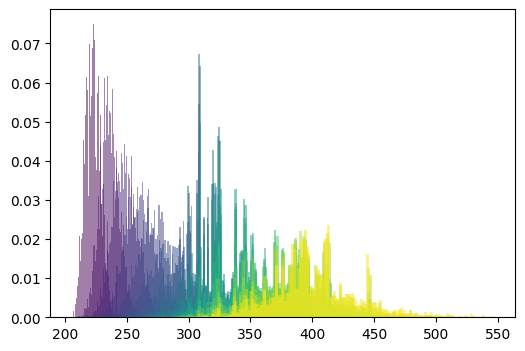

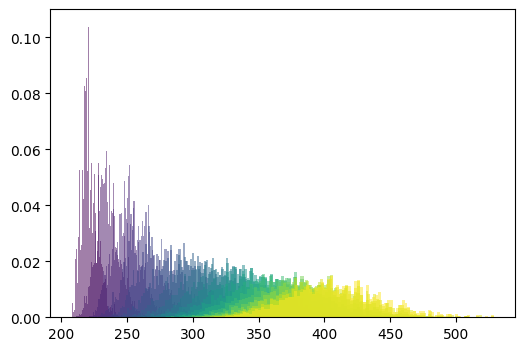

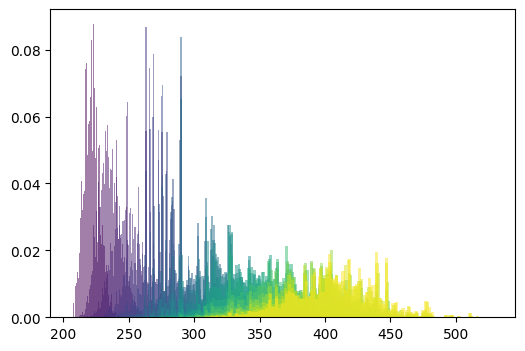

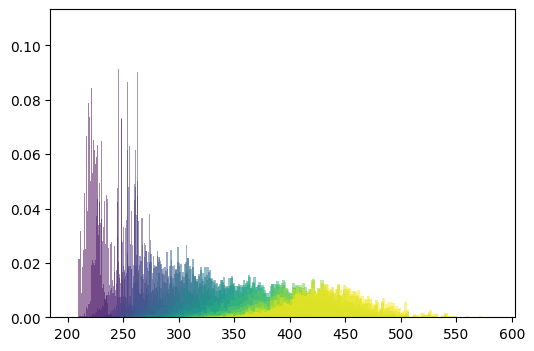

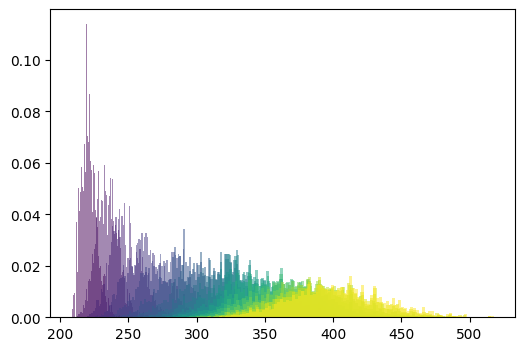

In [18]:
limit_grid = np.linspace(80, 190, 100)
bin_grid = limit_grid[:-1]
mean_energies = np.zeros((resamp_nch, nt))
energy_stds = np.zeros((resamp_nch, nt))

for k in range(resamp_nch):
    fig, ax = plt.subplots(figsize=(6, 4))
    for j in range(nt):
        ax.hist(energy_samples[j, k], bins = 100, color = temp_colors[j], label = f"temp {temp_centers[j]}", alpha = 0.5, density = True)
        mean_energies[k,j]  = np.mean(energy_samples[j, k])
        energy_stds[k,j]  = np.std(energy_samples[j, k])
    
    plt.savefig(f"{output_dir}/temp_pic_chain_{k}.jpg")
    plt.show()

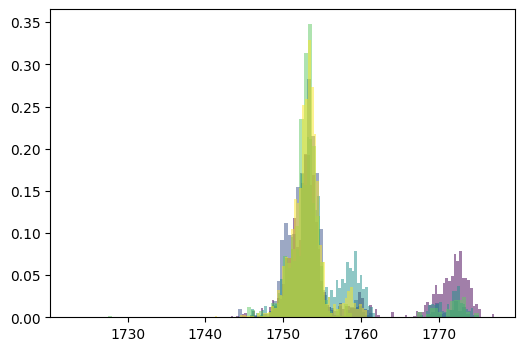

In [19]:
CV_values = data["th"] - data["dc"] * np.sum(resampled_samples[:, :, :index], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(resamp_nch):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.savefig(f"{output_dir}/resampling_along_depth_{interesting_depth}.jpg")
plt.show()

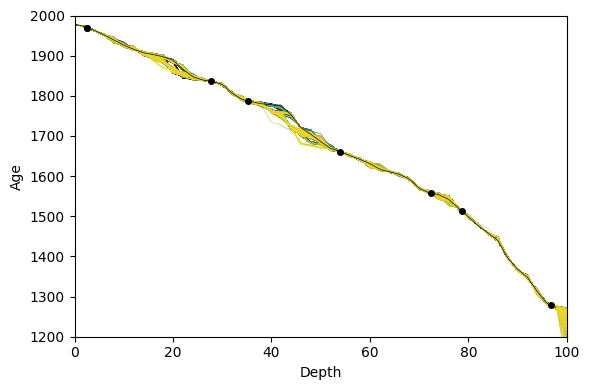

In [20]:
cumulative_sums = np.cumsum(resampled_samples, axis=2) * data["dc"]
zeros = np.zeros((*resampled_samples.shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["th"] - age_offsets

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(resamp_nch):
    for j in range(num_samples):
        ax.plot(
            data["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )

ax.set_xlim(0, np.max(data["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(f"{output_dir}/age_depth.jpg")
plt.show()

In [21]:
base_dir = Path.cwd()

df = np.load(f"{output_dir}/df.npy")
print(df.shape)

(5, 10000, 20)


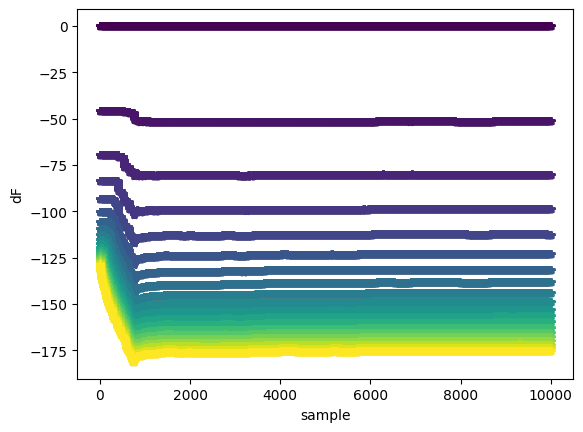

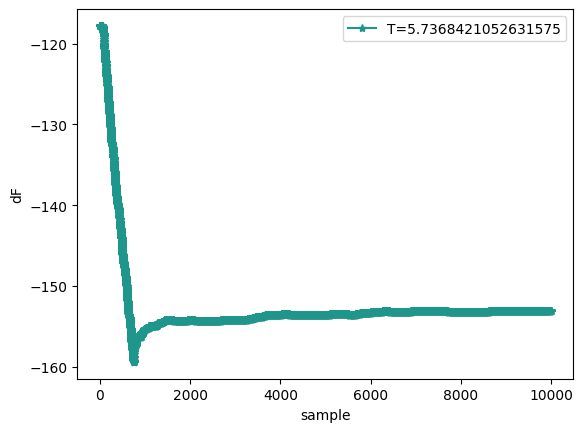

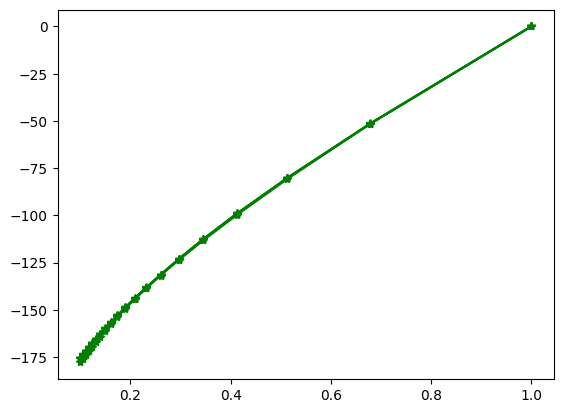

In [22]:
fig, ax = plt.subplots()
chain = 0

x = np.linspace(0, hmc_config["ns"]-1, hmc_config["ns"])
for k in range(nt):
    sample_delta_F = np.squeeze(df[chain, :, k])
    ax.plot(x[:], sample_delta_F, '*-', color = temp_colors[k], label = f"T={temp_centers[k]}")

plt.xlabel(f"sample")
plt.ylabel("dF")
plt.savefig(f"{output_dir}/df.jpg")
plt.show()

fig, ax = plt.subplots()
sample_delta_F = np.squeeze(df[chain, :, int(opes_config["nt"]/2)])
ax.plot(x, sample_delta_F, '*-', color = temp_colors[int(opes_config["nt"]/2)], label = f"T={temp_centers[int(opes_config["nt"]/2)]}")
plt.legend()
plt.xlabel(f"sample")
plt.ylabel(f"dF")
plt.savefig(f"{output_dir}/df_last.jpg")
plt.show()

plt.figure()
for i in range(hmc_config["nch"]):
    plt.plot(betas, df[i, -1, :], marker = '*', color = "green")

plt.savefig(f"{output_dir}/df_to_beta.jpg")
plt.show()